# [실습] 사고 경험률 표 — 믿을 수 있는 세그먼트 구분

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 오늘의 질문과 데이터

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">모형추정 심화통계 · Day 1</div>
<h1 style="color:#000000;margin:10px 0">사고 경험률 표 — 믿을 수 있는 세그먼트 구분</h1>
<div style="font-size:1.05em;color:#656565">프랑스 자동차보험 실계약 678,013건에서 요율표에 그대로 적을 세그먼트를 구분합니다</div>
</div>

## 오늘 할 일

여러분은 자동차보험사의 **프라이싱(요율 산정) 분석가**입니다. 오늘의 질문은 하나예요 — **"계약 하나가 사고를 겪을 확률을 우리 기록에서 가장 그럴듯하게 추정하면 얼마이고, 그 숫자를 요율표의 어느 세그먼트까지 그대로 옮겨 적어도 되는가."** **세그먼트** 는 지역·차종·마력 같은 조건의 조합 하나, 그리고 그 조합에 속한 계약 n건을 뜻합니다 — 요율표의 한 행이 세그먼트 하나예요. 이론에서 세운 우도와 최대우도추정(MLE)을 실계약 데이터에 그대로 적용합니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Binomial_distribution_pmf.svg" width="560" height="373"/>
<p align="center"><em>▲ 계약 n 건 중 사고를 겪은 계약이 k 건일 확률 — 계약 20건에 사고 확률 0.5 이면 k = 10 이 가장 잦고(확률 0.176), 오늘은 반대로 관측된 k 에서 그 확률을 되짚는다 (출처: Wikimedia Commons, Binomial distribution pmf.svg)</em></p>

<details class="lms-extra"><summary>자세히 — 위 그림의 가로축과 색 읽는 법</summary>

가로축은 사고를 겪은 계약 수 k 이고, 세로축은 그 k 가 나올 확률입니다. 파랑과 초록은 계약 20건에서 사고 확률이 0.5 일 때와 0.7 일 때이고, 빨강은 같은 0.5 를 계약 40건에서 본 것입니다. 계약 하나가 0 또는 1 을 내놓는 이 구조가 오늘 다루는 데이터와 같습니다.

</details>

미션 셋으로 전체 값 하나에서 세그먼트별 값까지 내려가고, 세그먼트마다 판정을 붙이는 과제로 마무리합니다. 수업에서 함께 도는 것은 미션 1·2 와 정리이고, 미션 3 과 과제는 방과후 몫이에요.

## 오늘의 데이터

**freMTPL2freq** 는 프랑스 자동차 책임보험의 실제 계약 기록입니다. 계약 한 건이 한 행이고 678,013행 × 12컬럼이며, 공개 저장소 OpenML 에서 로그인 없이 내려받습니다. 처음 한 번은 내려받느라 조금 걸려요. 받자마자 아래 규칙 셋을 고정하고, 뒤쪽 미션은 여기에 지역 `Region` · 차종 `VehBrand` · 마력 등급 `VehPower` 셋을 세그먼트를 가르는 기준으로 더해 씁니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Japanese_car_accident.jpg" width="640" height="360"/>
<p align="center"><em>▲ 교차로 접촉 사고 — 오늘 다루는 데이터의 한 행 한 행은 이런 현장들의 기록이다. 계약이 사고를 겪을 확률을 역산해 요율표의 세그먼트를 채우는 것이 이번 실습의 목표 (출처: Wikipedia, Japanese_car_accident.jpg)</em></p>

| 컬럼 | 뜻 | 받자마자 고정하는 규칙 |
|---|---|---|
| `ClaimNb` | 보험 기간 중 사고(청구) 건수 (건) | 상한 4건에서 절사 — 네 건을 넘는 사고가 적힌 계약이 소수 섞여 있어, 그 몇 건이 전체 평균을 크게 왜곡하지 않도록 두는 관례적인 전처리입니다 |
| `Exposure` | 그 계약이 실제로 유지된 기간 (년) | 상한 1.0년에서 절사 — 1년을 넘겨 적힌 계약이 소수 섞여 있어 같은 이유로 자릅니다 |
| `HasClaim` | **사고를 겪었는가** (0 또는 1) | `ClaimNb > 0` 을 0/1 로 바꿔 새로 만듭니다 — 오늘 분석하는 변수가 이 한 열입니다. 이 열을 더하면 표가 13열이 되어, 미션 1 준비 셀은 `(678013, 13)` 을 찍습니다 |

오늘은 「몇 건을 냈는가」가 아니라 「겪었는가 아닌가」만 셉니다. 계약마다 유지 기간이 다른 것을 값에 반영하는 이야기는 내일 다시 꺼냅니다.

## 이 노트북을 쓰는 법

**환경 안내** — ▶ 실행은 Google Colab 연결 안내를 따르고, 튜터는 상단 「Claude 도우미」 설치 뒤 씁니다(온보딩 레슨 참고). **채점은 Colab 이 연결되면 자동으로 준비됩니다 — 코드 패널 머리의 「채점 준비됨」이 뜬 뒤 미션을 시작하고, 미션 셀을 실행했는데 채점 결과가 안 찍히면 그 「채점 준비됨」을 누르세요.**

노트북을 내려받아 Colab 이나 내 컴퓨터에서 열었다면 맨 위의 접힌 `[채점]` 셀을 한 번 ▶ 실행한 뒤 시작합니다(코드는 접혀 있어도 실행됩니다). 도우미 대신 아무 AI 에 PROMPT 를 붙여 넣어 받은 코드를 `# --- 여기부터 AI 코드 ---` 행 아래에 직접 붙입니다. 채점이 끝나 🔓 가 뜨면 그 아래 「🔓 완성본 풀이 보기」를 펼쳐 내 코드와 견줍니다.

**맨 위 두 셀을 먼저 실행하세요 — 설치·폰트 셀은 한 번이면 되고, 채점 셀은 LMS 가 자동으로 실행합니다.** 미션마다 코드 셀이 둘입니다. 앞의 것은 **준비 셀** 이라 그대로 실행하고, 뒤의 것은 **PROMPT 셀** 이라 시킬 일을 적습니다. 「준비 셀」이 그 미션에 쓸 변수를 처음부터 만들어 주니, 뒤쪽 미션만 따로 열어도 그 셀부터 실행하면 됩니다.

PROMPT 셀의 `PROMPT` 에 시킬 일을 내 말로 적어 AI 에게 넘기면, `# --- 여기부터 AI 코드 ---` 행 아래가 AI 가 코드를 넣는 자리가 됩니다. 실행하는 순간 **실행 결과(출력)에 채점 결과**가 찍혀요. 기준에 닿으면 완성본 풀이가 열리고, 어긋나면 어긋난 자리와 튜터에 보낼 질문이 나옵니다. 변수 이름은 자유예요 — 채점은 이름이 아니라 출력과 그림을 봅니다.

**주고받기 규칙 둘** — AI 와 막혔을 때는 이 둘만 지킵니다.

| 이럴 때 | 이렇게 합니다 |
|---|---|
| 같은 말을 두 번째 되풀이하게 될 때 | 말을 바꾸지 말고 `PROMPT` 에 **빠진 조건을 하나** 더합니다 |
| 조건을 더해도 안 될 때 | 앞 대화를 이어 붙이지 말고, 요구를 한 덩어리로 다시 적어 새 메시지로 보냅니다 |

In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7" "seaborn>=0.13" "scikit-learn>=1.3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.optimize import minimize
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150      # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True                            # 여백은 tight_layout 이 알아서
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     # 위 테두리·오른쪽 테두리·격자를 걷어내 데이터만 남긴다
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림들이 함께 쓰는 색 — 우도 곡선=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3", "참값": "#757575"}
FIG_W = 10.0     # 캔버스 폭은 모두 이 값으로 고정하고 높이만 그림마다 조절한다

print("사용 폰트:", FONT,
      "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

사용 폰트: NanumGothic | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


## 사고 경험률의 봉우리를 소수점까지 짚을 수 있을까

### 미션 1 — 계약 전체의 사고 경험률을 한 숫자로

#### 할 일 — 미션 1 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 아래 만들 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
3. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
4. 실행 결과(출력)에 찍히는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.

**이 미션의 질문** — 계약 678,013건을 한 덩어리로 놓으면 사고 경험률은 얼마입니까?

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Lawoflargenumbers.svg" width="560" height="373"/>
<p align="center"><em>▲ 이 미션의 질문 — 주사위를 굴린 횟수와 그때까지의 관측 평균. 가로축이 시행 횟수, 세로축이 평균, 파란 가로선이 이론값 3.5 다. 초록 선은 맨 처음 몇 회에 5.5 까지 치솟고 100회 안쪽에서도 3.1 과 4 사이를 오가지만, 600회를 넘기면 두 선이 거의 붙는다. 계약 67만 8천 건을 한 덩어리로 놓는 근거가 오른쪽 구간이다 (출처: Wikimedia Commons, Lawoflargenumbers.svg)</em></p>

#### 실행 전에 — 계획을 골라 보세요

계약 전체의 사고 경험률을 구하는 절차로 어느 쪽을 쓸까요? 하나를 고르고, 왜 그것이 보고서의 근거가 되는지 한 문장 적으세요.

> **[예측] 계약 전체의 사고 경험률을 구하는 절차로 어느 쪽을 쓸까요?**
>
> 1. 계약별 사고 건수의 평균을 그대로 쓴다
> 2. 사고를 겪은 계약 수를 전체 계약 수로 나눈다
> 3. 베르누이 로그우도를 세워 그 최댓값을 주는 p 를 수치 최적화로 찾는다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

덧붙여, 셋 중 **둘은 같은 값에 도착합니다**. 어느 둘일지도 적어 두세요.

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `y` | 계약별 사고 유무 0/1, 678,013건 | 고정 |
| `n_all` | 전체 계약 수, 단위 건 | 고정 |
| `bern_nll(p)` | p 를 받아 음의 로그우도를 돌려주는 함수 | 그대로 부른다 |

여기서 $k$ 는 사고를 겪은 계약 수, $n$ 은 전체 계약 수입니다. **음의 로그우도** 는 로그우도에 마이너스를 붙여 최댓값 찾기를 최솟값 찾기로 바꾼 값이라, `bern_nll` 을 가장 작게 만드는 p 가 곧 우도를 가장 크게 만드는 p 입니다.

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 다 나오게 합니다.

1. **사고 경험률** — 단위 비율 · 소수 여섯 자리 · `bern_nll` 을 수치 최적화로 가장 작게 만드는 p
2. **사고를 겪은 계약 수** — 단위 건 · 정수 · `y` 를 전부 더한 값
3. **덧붙일 한 행** — 공식으로 바로 구하는 해(closed-form) $k/n$ · 수렴 여부 · 반복 횟수
   - 채점이 보는 값은 아니고, 통과 뒤 열리는 완성본과 대조할 자리예요
4. **그래프 한 장** — 가로축은 후보 사고 경험률 p 0.02 ～ 0.10, 세로축은 로그우도인 선 그래프
   - 곡선 : 후보 p 를 촘촘히 늘어놓은 로그우도 곡선 하나
   - 수직선 : 1번에서 찾은 p 자리에 하나
   - 가로축 이름 : 「후보 사고 경험률 p (비율)」
   - 세로축 이름 : 「로그우도」

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Nelder-Mead_Rosenbrock.gif" width="440" height="440"/>
<p align="center"><em>▲ 만들 것 1번 — 수치 최적화가 목적함수 위를 더듬어 최솟값으로 내려가는 모습. 빨간 삼각형이 후보를 옮겨 가며 최솟값을 찾아가고, 검은 곡선은 목적함수의 등고선이다. <code>minimize</code> 에 넘길 목적함수가 바로 음의 로그우도다 (출처: Wikipedia, Nelder-Mead_Rosenbrock.gif)</em></p>

그림은 변수 둘(x1, x2)을 움직인 예입니다. 미션 1 은 후보 하나만 움직이는 1차원 문제라, 삼각형 대신 점 하나가 좌우로 옮겨 갑니다.

**출력 형식** — 「이름 = 값 단위」 꼴로 한 행씩 `print` 합니다. 그래프는 한 장입니다.

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름** — `y` · `n_all` · `bern_nll` 은 이미 있으니 다시 만들지 말라고 적습니다.
- **최소화 대상** — 어느 함수를 가장 작게 만드는 p 를 찾는지, 후보 p 가 0 과 1 사이라는 것.
- **출력** — 값 두 개의 이름과 단위, 그리고 소수 몇 자리까지 찍을지.
- **그래프** — 가로축 범위 · 세로축이 로그우도라는 것 · 수직선이 설 자리 · 가로축·세로축 이름.

**막히면** — AI 튜터에게 「최소화 함수에 목적함수와 시작값을 어떻게 넘기나요」 처럼 물어보세요.

<details class="lms-extra"><summary>배경 — 이론 3절에서 이어지는 자리, 그리고 음의 로그우도라는 이름</summary>

이론 3절에서 베르누이의 최대우도추정이 사고를 겪은 계약 수를 전체 계약 수로 나눈 값, 곧 $k/n$ 으로 떨어지는 것을 보았죠. 오늘은 같은 값을 다른 길로 다시 구합니다 — 음의 로그우도를 가장 작게 만드는 $p$ 를 수치 최적화로 찾아, 공식으로 바로 구하는 해와 나란히 놓고 견줍니다.

**NLL(negative log-likelihood)** 은 로그우도에 마이너스를 붙여 **최댓값 찾기를 최솟값 찾기로 바꾼 것**입니다. 최적화 도구가 대개 최솟값을 찾도록 만들어져 있어서죠. 부호만 뒤집었으니 답이 놓이는 가로 위치, 즉 $p$ 는 그대로입니다. 세로축을 NLL 로 그리면 곡선이 상하로 뒤집혀 보이고, 최댓값 지점이 최솟값 지점 자리에 섭니다.

</details>

<details class="lms-extra"><summary>주의 — 도우미에 맡길 일과 내가 볼 일</summary>

도우미가 코드를 넣는 자리는 마지막으로 클릭한 코드 셀입니다. 다른 셀을 클릭한 채 시키면 엉뚱한 셀이 바뀝니다.

왼쪽은 문법과 틀 잡기라 맡겨도 되는 일이고, 오른쪽은 **틀려도 오류가 나지 않아** 사람이 봐야 하는 일이에요.

| AI 에게 맡길 일 | 내가 반드시 확인할 일 |
|---|---|
| 최적화 호출 코드와 인자 채우기 | 최소화 대상이 **음의** 로그우도인가 |
| 후보 $p$ 몇 개의 값을 나란히 출력 | 세는 것이 사고 **건수**가 아니라 사고를 겪은 **계약 수**인가 |
| 로그우도 곡선을 그리고 수직선 얹기 | 수렴에 성공했는가, 값이 비율로 말이 되는가 |

</details>

In [2]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 변수를 직접 만듭니다
from sklearn.datasets import fetch_openml

# freMTPL2freq — 프랑스 자동차보험 계약별 사고 기록 (678,013 x 12). OpenML 에서 바로 내려받습니다
df = fetch_openml(data_id=41214, as_frame=True).frame
df["IDpol"] = df["IDpol"].astype(int)
for c in ["Area", "VehBrand", "VehGas", "Region"]:
    df[c] = df[c].astype(str).str.strip("'").astype("category")

# 받자마자 고정하는 전처리 두 규칙 — 오늘 내내 이대로 씁니다
df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)   # 사고 5건 이상은 극소수라 상한 4 로 절사
df["Exposure"] = df["Exposure"].clip(upper=1.0)           # 유지 기간은 1년 상한
# 오늘 분석할 변수 — 사고를 겪었는가 아닌가
df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)

y = df["HasClaim"].to_numpy(dtype=float)     # 쓸 변수 1 — 계약별 사고 유무 (0 또는 1)
n_all = int(len(y))                          # 쓸 변수 2 — 전체 계약 수 (단위 건)


def bern_nll(p):                             # 쓸 변수 3 — 베르누이의 음의 로그우도
    """p 는 0 과 1 사이 숫자 하나 또는 길이 1 배열. 최소화용이라 로그우도에 마이너스를 붙여 돌려줍니다"""
    p = float(np.atleast_1d(p)[0])
    if not 0.0 < p < 1.0:
        return 1e12                          # 범위 밖 후보에는 큰 벌점
    n_claimed = float(y.sum())
    return -(n_claimed * np.log(p) + (n_all - n_claimed) * np.log(1.0 - p))


print("행 x 열 :", df.shape, "| 결측치 총합 :", int(df.isna().sum().sum()))
print("전체 계약 수 :", f"{n_all:,}", "건")
print(df[["IDpol", "ClaimNb", "Exposure", "HasClaim", "VehPower", "Region"]].head())
print("쓸 수 있는 이름 : y (사고 유무 0/1) · n_all (전체 계약 수, 건) · bern_nll(p) (음의 로그우도)")

행 x 열 : (678013, 13) | 결측치 총합 : 0
전체 계약 수 : 678,013 건
   IDpol  ClaimNb  Exposure  HasClaim  VehPower Region
0      1        1      0.10         1         5    R82
1      3        1      0.77         1         5    R82
2      5        1      0.75         1         6    R22
3     10        1      0.09         1         7    R72
4     11        1      0.84         1         7    R72
쓸 수 있는 이름 : y (사고 유무 0/1) · n_all (전체 계약 수, 건) · bern_nll(p) (음의 로그우도)


사고 경험률 = 0.050235 비율
사고를 겪은 계약 수 = 34060 건
closed-form k/n = 0.050235, converged = True, iterations = 15

──────────────────────────────────────────────────────
◼ 미션 1 채점 결과
✅ 사고 경험률 (비율) — 출력에서 0.050235 를 찾았습니다
✅ 사고를 겪은 계약 수 (건) — 출력에서 34,060 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
──────────────────────────────────────────────────────


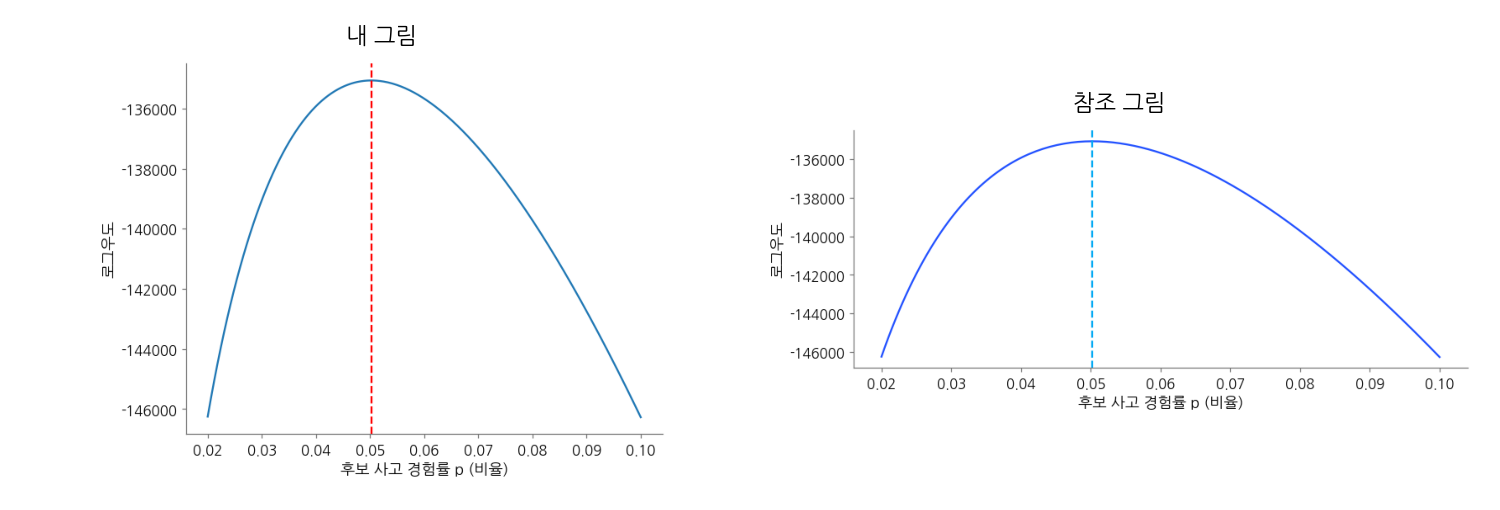

In [3]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
[전제]
y, n_all, bern_nll 은 이미 정의되어 있으므로 다시 만들지 말고 그대로 사용한다.

[할 일]
아래 네 가지를 계산/출력하는 코드를 PROMPT 셀 한 곳에 작성한다.

1. 사고 경험률
   - bern_nll(p) 을 p ∈ (0, 1) 범위에서  수치 최적화하여 가장 작게 만드는 p를 찾는다.
   - 단위: 비율, 소수 여섯 자리로 출력

2. 사고를 겪은 계약 수
   - y 를 전부 더한 값
   - 단위: 건, 정수로 출력

3. 덧붙일 한 행 
   - closed-form 해 k/n (k = y의 합, n = n_all)
   - 수치 최적화의 수렴 여부(converged: True/False)
   - 반복 횟수(iterations)
   를 한 행으로 함께 출력

4. 그래프 한 장
   - 가로축: 후보 사고 경험률 p, 범위 0.02 ~ 0.10
   - 세로축: 각 p에서의 로그우도(=-bern_nll(p))
   - 선 그래프로 로그우도 곡선 하나를 그린다
   - 1번에서 찾은 최적 p 위치에 수직선을 하나 긋는다
   - 가로축 이름: 후보 사고 경험률 p (비율)
   - 세로축 이름: 로그우도

[출력 형식]
- 값 두 개(1번, 2번)는 각각 "이름 = 값 단위" 형태로 한 행씩 print 한다.
- 3번도 같은 형식으로 한 행 print 한다.
- 그래프는 한 장만 생성한다.

"""
# --- 여기부터 AI 코드 ---
from scipy.optimize import minimize_scalar
import numpy as np
import matplotlib.pyplot as plt

# 1. 사고 경험률: bern_nll(p)을 (0,1) 구간에서 최소화
res = minimize_scalar(bern_nll, bounds=(1e-6, 1 - 1e-6), method='bounded')
p_hat = res.x
print(f"사고 경험률 = {p_hat:.6f} 비율")

# 2. 사고를 겪은 계약 수
k = int(np.sum(y))
print(f"사고를 겪은 계약 수 = {k} 건")

# 3. closed-form vs 수치 최적화 비교
k_over_n = k / n_all
print(f"closed-form k/n = {k_over_n:.6f}, converged = {res.success}, iterations = {res.nit}")

# 4. 로그우도 곡선 + 최적 p 수직선
p_grid = np.linspace(0.02, 0.10, 400)
loglik = np.array([-bern_nll(p) for p in p_grid])

plt.figure()
plt.plot(p_grid, loglik)
plt.axvline(p_hat, color='red', linestyle='--')
plt.xlabel("후보 사고 경험률 p (비율)")
plt.ylabel("로그우도")
plt.show()

> **[문제] 미션 1 의 「여기부터 AI 코드」 행 아래 코드에서 `minimize` 에 넘긴 목적함수가 `bern_nll` 인 것이 결과에 어떻게 작용하나요?**
>
> 1. 로그우도를 그대로 넘긴 것과 같아, 최적화가 최댓값 지점을 향해 올라간다
> 2. 부호를 뒤집어 최솟값을 찾게 만든 것이라, 찾은 p 는 로그우도가 최대가 되는 p 와 같다
> 3. 부호를 뒤집었으므로 찾은 p 도 뒤집혀, 로그우도 최대 지점과는 다른 값이 나온다

## 표준오차가 0 으로 찍힌 세그먼트는 정말 가장 확실한가

### 미션 2 — 세그먼트마다 ±2SE 를 재고 계약 수가 적은 세그먼트를 구분한다 (함정 미션)

#### 할 일 — 미션 2 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 「PROMPT 셀」을 **먼저 그대로 ▶** 해 전임 담당자 코드의 채점 결과(❌)를 봅니다.
3. 아래 고칠 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
4. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
5. 실행 결과(출력)에 찍히는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 4번부터 다시 합니다.

**이 미션의 질문** — 계약 수가 적은 세그먼트 가운데 ±2SE 가 0 으로 찍힌 곳이 정말 가장 확실한 곳입니까?

**±2SE** 는 표준오차 × 2, 곧 구간 한쪽 길이입니다. 구간 전체가 아니라 이 숫자를 찍습니다.

#### 고치기 전에 — 어디가 틀렸는지 먼저 찾아보세요

「여기부터 AI 코드」 아래를 한 행씩 읽고, 사고가 0건인 세그먼트를 ±2SE 공식에 손으로 넣어 보세요.

> **[예측] 「여기부터 AI 코드」 행 아래 코드는 오류 없이 돌아가는데 답이 틀렸습니다. 틀린 곳은 어디일까요?**
>
> 1. ±2SE 공식의 분모가 계약 수 n 이 아니라 n − 1 이다
> 2. 사고가 0건인 세그먼트에서 ±2SE 가 0 으로 나오는데, 그 0 을 「추정값이 안정되었다」로 읽어 순위 맨 앞에 뒀다
> 3. 2 를 곱하지 않아 ±2SE 가 절반으로 나온다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

찾은 자리에 근거를 한 문장 적고, 몇 개 세그먼트가 순위에서 빠질지도 적어 두세요.

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `seg3` | 세그먼트 2,323행 표, 열은 `n` · `k` · `c` · `p_mle` | 고정 |
| `p_all` | 전체 계약(회사 전체)의 사고 경험률, 단위 비율 — 이번 미션에서는 쓰지 않고 과제에서 판정 기준값으로 씁니다 | 고정 |

#### 고칠 것

「여기부터 AI 코드」 행 아래에 전임 담당자 코드가 이미 들어 있습니다. 오류 없이 돌아가는데 값이 틀렸고 그림이 없어요. 고친 뒤의 아래 넷이 이 미션에서 만들 것입니다.

1. **계약 40건 세그먼트의 ±2SE** — 단위 비율 · 소수 여섯 자리
   - 지금 : ±2SE 가 좁은 순서로 줄을 세운 뒤 맨 앞 행의 값을 찍습니다
   - 고친 뒤 : 이론 3절 퀴즈에서 손으로 ±2SE 를 재 본 그 세그먼트(계약 40건 · 사고 3건)를 `n` 과 `k` 로 직접 골라 그 행의 ±2SE 를 찍습니다
2. **±2SE 를 계산할 수 없는 세그먼트 수** — 단위 개 · 정수
   - 지금 : `isna()` 로 세어 0 개가 나옵니다
   - 고친 뒤 : 결측이 아니라 다른 조건으로 직접 셉니다
3. **그래프 한 장** — 가로축은 세그먼트의 계약 수, 세로축은 그 세그먼트의 사고 경험률인 산점도
   - 점 : 세그먼트 하나에 점 하나, 모두 2,323개
   - 가로축 눈금 : 로그 눈금 — 눈금 한 단계가 10배씩 벌어집니다. matplotlib 에서는 `set_xscale` 한 행이에요
   - 가로축 이름 : 「세그먼트의 계약 수 (건, 로그 눈금)」
   - 세로축 이름 : 「사고 경험률 (비율)」
   - 지금 : 그림이 없습니다. 같은 프롬프트에서 새로 시켜야 나옵니다
4. **남길 다섯 행** — ±2SE 가 좁은 순서로 다섯 세그먼트를 그대로 남겨 둡니다
   - 채점이 보는 값은 아니고, 고치기 전과 뒤에 어떤 세그먼트가 앞자리에 오는지 볼 자리예요

<img src="https://en.wikipedia.org/wiki/Special:FilePath/FloreAndWicherts2015_meta_analysis_sex_stereotype_threat.png" width="480" height="449"/>
<p align="center"><em>▲ 고칠 것 3번 — 깔때기 그림(funnel plot). 가로축이 추정값, 세로축이 표준오차이고 아래로 갈수록 표본이 작아 좌우로 넓게 흩어진다. 우리 산점도는 이것을 90° 돌려 본 것이라 계약이 적은 왼쪽에서 세로로 벌어진다 — 계약 1건 세그먼트는 0 과 1 양 끝에, 18,042건 세그먼트는 한 자리에 모인다 (출처: Wikimedia Commons, Flore &amp; Wicherts 2015 funnel plot)</em></p>

**통과 기준** — 값 둘이 「이름 = 값 단위」 꼴로 한 행씩 찍히고, 산점도 한 장이 위 요구를 다 갖추면 통과입니다.

#### 프롬프트에 넣을 것(힌트)

- **고칠 자리** — 어느 값을 어떤 조건으로 다시 고를지, 세는 법을 무엇으로 바꿀지.
- **손대지 말 범위** — `seg3` 는 이미 있으니 표를 다시 만들지 말고 `n` · `k` · `c` · `p_mle` 열을 그대로 쓰라고 적습니다.
- **출력** — 값 두 개의 이름과 단위, 그리고 소수 몇 자리까지 찍을지.
- **그래프** — 가로축·세로축에 무엇을 놓을지 · 가로축 눈금 · 이름을 다는 것.

**막히면** — AI 튜터에게 「사고가 한 건도 없는 세그먼트에 ±2SE 공식을 넣으면 어떤 값이 나오나요」 처럼 물어보세요.

<details class="lms-extra"><summary>배경 — 이론 3절의 ±2SE 를 세그먼트 2,323개에 적용하는 자리</summary>

미션 1 에서 계약 678,013건을 한 덩어리로 놓고 사고 경험률 한 숫자를 얻었죠. 요율표는 그 한 숫자로 끝나지 않습니다. 지역·차종·마력이 다른 세그먼트마다 값을 따로 적어야 하고, 세그먼트의 계약 수가 적을수록 그 값이 표본에 따라 얼마나 달라지는지도 같이 적어야 해요.

이론 3절에서 **±2SE 구간**(추정값 ± 표준오차의 2배)을 「표본에 따라 추정값이 달라지는 범위」로 정의했고, 계약이 줄면 그 구간이 벌어지는 것도 보았죠. 위에서 「±2SE」라고 적는 숫자는 그 ± 뒤에 붙는 값, 곧 구간 한쪽의 길이입니다. ±2SE 가 좁은 세그먼트일수록 요율표에 그대로 옮겨 적기 좋은 세그먼트이니, 좁은 순서로 순위를 매기는 것이 전임 담당자의 계획이었어요.

**±2SE 를 계산할 수 없는 세그먼트**는 사고가 0건이거나 계약 전부가 사고를 겪은 세그먼트입니다. 값은 0 으로 멀쩡히 나오지만 그 0 은 표본에 따른 차이를 잰 값이 아니라서, 순위에 올리지 않고 판정에서 제외합니다.

**로그 눈금(log scale)** 은 눈금 한 단계가 10배씩 벌어지는 눈금입니다. 세그먼트마다 계약 수가 1건부터 18,042건까지 섞여 있어, 보통 눈금에서는 점이 왼쪽 끝에 뭉쳐 모양이 안 보이거든요. matplotlib 에서는 `ax.set_xscale("log")` 한 행입니다.

</details>

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Confidence_interval.png" width="600" height="478"/>
<p align="center"><em>▲ 같은 모집단에서 표본을 여러 번 뽑아 그때마다 95% 구간을 그린 그림 — 막대 13개 가운데 맨 위 막대 하나가 참값 세로선을 비껴가듯, ±2SE 구간은 추정값이 표본에 따라 달라지는 범위이지 참값을 보증하는 표가 아니다 (출처: ultrabem.com via Wikimedia Commons, Confidence interval.png)</em></p>

위 신뢰구간 그림에서 — 세로선이 우리가 끝내 모르는 참값이고, 가로 막대 하나가 표본 하나의 95% 구간입니다. 막대의 길이가 표본마다 다른 것처럼, 세그먼트마다 계약 수가 달라 ±2SE 구간의 길이도 달라집니다.

In [4]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 맨 위 두 셀을 실행한 뒤에는 이 미션만 따로 열어도 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)       # 오늘 고정한 전처리 두 규칙 — 미션 1 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)
    df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)              # 오늘 분석할 변수 — 사고를 겪었는가 아닌가

# 쓸 변수 1 — 지역 x 차종 x 마력으로 가른 세그먼트 표. 한 행이 요율표의 세그먼트 하나입니다
seg3 = (df.groupby(["Region", "VehBrand", "VehPower"], observed=True)
          .agg(n=("IDpol", "size"),        # n — 그 세그먼트의 계약 수 (건)
               k=("HasClaim", "sum"),      # k — 그중 사고를 겪은 계약 수 (건)
               c=("ClaimNb", "sum"))       # c — 그 세그먼트의 사고 건수 합 (건, 오늘은 쓰지 않습니다)
          .reset_index())
seg3["p_mle"] = seg3["k"] / seg3["n"]      # p_mle — 그 세그먼트의 사고 경험률 = k / n (비율)

p_all = float(df["HasClaim"].mean())       # 쓸 변수 2 — 전체 계약(회사 전체)의 사고 경험률 (비율)


def _2se(k, n):                            # 이론 3절의 ±2SE — 표준오차 x 2
    p = k / n
    return 2 * (p * (1 - p) / n) ** 0.5


_c63 = (seg3[(seg3["n"] == 63) & (seg3["k"] == 4)]
        .sort_values(["Region", "VehBrand", "VehPower"]).iloc[0])
_r43 = df.loc[df["Region"] == "R43", "HasClaim"]

print(f"세그먼트 수 : {len(seg3):,} 개 | 계약 합 : {int(seg3['n'].sum()):,} 건"
      f" | 사고를 겪은 계약 합 : {int(seg3['k'].sum()):,} 건")
print(f"세그먼트의 계약 수 — 가장 적은 세그먼트 {int(seg3['n'].min()):,} 건 ·"
      f" 가운데 {int(seg3['n'].median()):,} 건 · 가장 많은 세그먼트 {int(seg3['n'].max()):,} 건")
print("\n이론 3절에서 본 세 행 — 계약이 줄면 ±2SE 가 어떻게 벌어지는가")
for name, k, n in [("전체 계약", int(df["HasClaim"].sum()), len(df)),
                  ("지역 R43", int(_r43.sum()), int(_r43.size)),
                  ("계약 63건 세그먼트", int(_c63["k"]), int(_c63["n"]))]:
    print(f"  {name} : 계약 {n:,}건 · 사고 경험률 {k / n:.6f} · ±2SE {_2se(k, n):.6f}")
print("\n쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · p_all (전체 계약의 사고 경험률, 비율)")

세그먼트 수 : 2,323 개 | 계약 합 : 678,013 건 | 사고를 겪은 계약 합 : 34,060 건
세그먼트의 계약 수 — 가장 적은 세그먼트 1 건 · 가운데 41 건 · 가장 많은 세그먼트 18,042 건

이론 3절에서 본 세 행 — 계약이 줄면 ±2SE 가 어떻게 벌어지는가
  전체 계약 : 계약 678,013건 · 사고 경험률 0.050235 · ±2SE 0.000531
  지역 R43 : 계약 1,326건 · 사고 경험률 0.040724 · ±2SE 0.010856
  계약 63건 세그먼트 : 계약 63건 · 사고 경험률 0.063492 · ±2SE 0.061443

쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · p_all (전체 계약의 사고 경험률, 비율)


계약 40건 세그먼트의 ±2SE = 0.083292 비율
±2SE 를 계산할 수 없는 세그먼트 수 = 759 개
Region VehBrand  VehPower  n  k  p_mle  표준오차
   R72      B14         6 16  0    0.0       0.0
   R41       B6        11  5  0    0.0       0.0
   R42       B1         8 18  0    0.0       0.0
   R83      B11         4  2  0    0.0       0.0
   R83      B11         5  2  0    0.0       0.0

──────────────────────────────────────────────────────
◼ 미션 2 채점 결과
✅ 계약 40건 세그먼트의 ±2SE (비율) — 출력에서 0.083292 를 찾았습니다
✅ ±2SE 를 계산할 수 없는 세그먼트 수 (개) — 출력에서 759 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
──────────────────────────────────────────────────────


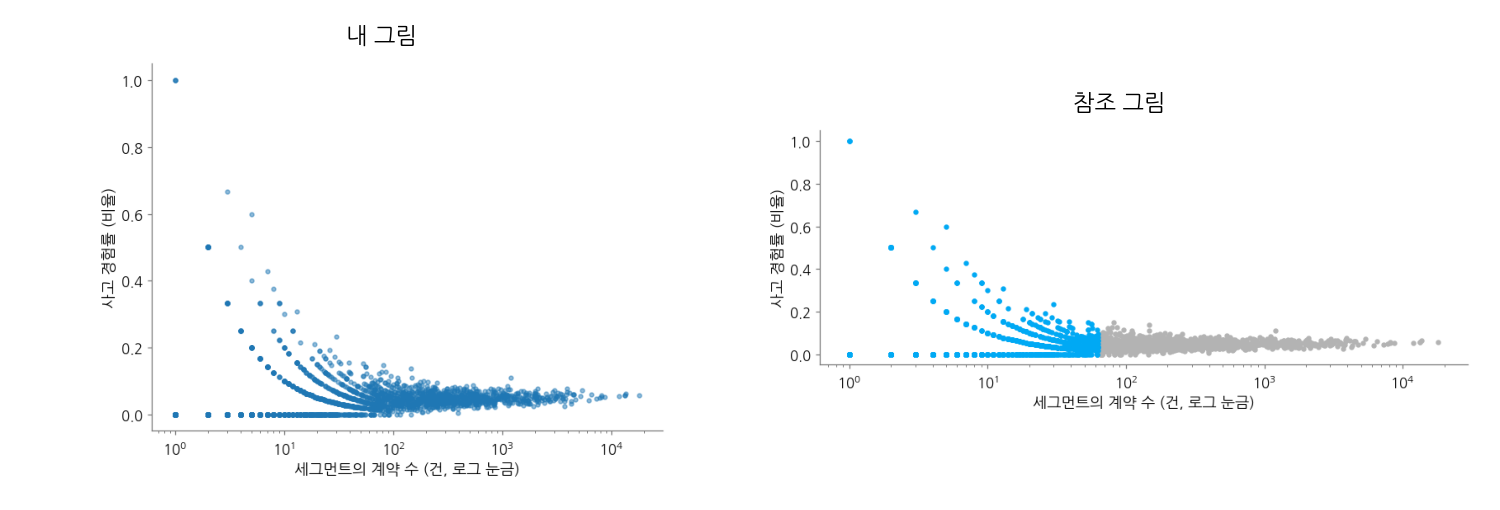

In [5]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 도우미가 구분선 아래를 다시 씁니다.
PROMPT = """
[전제]
seg3 는 이미 있으니 표를 다시 만들지 말고, n · k · c · p_mle 열을 그대로 사용한다.

[전임 담당자 코드 문제]
seg3["표준오차"] = 2 * np.sqrt(seg3["p_mle"] * (1 - seg3["p_mle"]) / seg3["n"])
narrow_se_first = seg3[seg3["n"] <= 63].sort_values("표준오차")        

[할 일]
아래 네 가지를 계산/출력하는 코드로 PROMPT 셀의
--- 여기부터 AI 코드 --- 행 아래 전임 담당자의 코드를 수정한다.

1. 계약 40건 세그먼트의 ±2SE
   - "±2SE가 좁은 순서로 정렬 후 맨 앞 행"을 찍는 방식이 아닌, n= 40, k=3인 세그먼트를 seg3에서 직접 조건으로 골라, 그 행의 ±2SE 값을 찍는다.
   - 단위: 비율, 소수 여섯 자리로 출력

2. ±2SE 를 계산할 수 없는 세그먼트 수 
   - isna()가 아닌,k=0(사고 0건, p_mle=0) 또는 k=n(전건 사고, p_mle=1)인 세그먼트를 센다.
   - 단위: 개, 정수로 출력

3. 그래프 한 장
   - 산점도 그래프로 그린다. 그래프는 지금 코드에 없으므로 새로 추가한다.
   - 가로축: 세그먼트의 계약 수 n, 세그먼트 하나에 점 하나(총 2,323개)
   - 세로축: 세그먼트의 사고 경험률
   - 가로축 로그 눈금은 한 단계가 10배씩 벌어진다.
   - 가로축 이름: 세그먼트의 계약 수 (건, 로그 눈금)
   - 세로축 이름: 사고 경험률 (비율)

4. 남길 다섯 행
    - ±2SE 가 좁은 순서로 상위 다섯 세그먼트를 그대로 출력한다.
    - 고치기 전과 후 어떤 세그먼트가 앞자리에 오는지 확인용

[출력 형식]
- 값 두 개(1번, 2번)는 각각 "이름 = 값 단위" 형태로 한 행씩 print 한다.
- 그래프는 한 장만 생성한다.
"""
# --- 여기부터 AI 코드 ---
# ↓ 전임 담당자의 코드 — 그대로 실행하면 채점이 ❌ 를 냅니다
# seg3["표준오차"] = 2 * np.sqrt(seg3["p_mle"] * (1 - seg3["p_mle"]) / seg3["n"])
# narrow_se_first = seg3[seg3["n"] <= 63].sort_values("표준오차")        # 계약 수가 적은 세그먼트 중 ±2SE 가 좁을수록 확실하다고 본 자리
# print(f"계약 40건 세그먼트의 ±2SE = {narrow_se_first['표준오차'].iloc[0]:.6f} 비율")
# print(f"±2SE 를 계산할 수 없는 세그먼트 수 = {int(seg3['표준오차'].isna().sum())} 개")
# print(narrow_se_first.head(5)[["Region", "VehBrand", "VehPower", "n", "k", "p_mle", "표준오차"]].to_string(index=False))
import matplotlib.pyplot as plt

seg3["표준오차"] = 2 * np.sqrt(seg3["p_mle"] * (1 - seg3["p_mle"]) / seg3["n"])

# 1. n=40, k=3인 세그먼트를 직접 선택
target = seg3[(seg3["n"] == 40) & (seg3["k"] == 3)]
print(f"계약 40건 세그먼트의 ±2SE = {target['표준오차'].iloc[0]:.6f} 비율")

# 2. k=0(사고 0건) 또는 k=n(전건 사고)인 세그먼트 수
n_undefined = int(((seg3["k"] == 0) | (seg3["k"] == seg3["n"])).sum())
print(f"±2SE 를 계산할 수 없는 세그먼트 수 = {n_undefined} 개")

# 3. 세그먼트별 계약 수 vs 사고 경험률 산점도
plt.figure()
plt.scatter(seg3["n"], seg3["p_mle"], s=10, alpha=0.5)
plt.xscale("log")
plt.xlabel("세그먼트의 계약 수 (건, 로그 눈금)")
plt.ylabel("사고 경험률 (비율)")
plt.show()

# 4. ±2SE가 좁은 순서로 상위 다섯 세그먼트
narrow_se_first = seg3[seg3["n"] <= 63].sort_values("표준오차")
print(narrow_se_first.head(5)[["Region", "VehBrand", "VehPower", "n", "k", "p_mle", "표준오차"]].to_string(index=False))

> **[문제] 미션 2 의 전임 담당자 코드에서 `seg3["표준오차"].isna().sum()` 이 0 을 돌려준 이유로 맞는 것은?**
>
> 1. `n` 이 0 인 세그먼트가 없어 나눗셈이 한 번도 실패하지 않았고, 사고가 0건인 세그먼트의 ±2SE 는 결측으로 남았다
> 2. 사고가 0건인 세그먼트도 제곱근 안이 0 이라 ±2SE 가 0 으로 멀쩡히 계산되어, 결측이 된 세그먼트가 한 곳도 없다
> 3. `isna()` 는 실수 열에서 언제나 0 을 돌려주므로, 결측이 있어도 세지 못한다

## 2등이 불가능하지 않다는 것을 자로 잴 수 있을까

### 미션 3 — 계약 수가 적은 세그먼트에 적어도 되는 값의 범위를 상대우도로 구한다

#### 할 일 — 미션 3 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 아래 만들 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
3. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
4. 실행 결과(출력)에 찍히는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.

**이 미션의 질문** — 계약 63건·사고 4건 세그먼트에 요율로 적어도 되는 값은 어디까지입니까?

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `seg3` | 세그먼트 2,323행 표, 열은 `n` · `k` · `c` · `p_mle` — 이번 미션에서 직접 쓰는 것은 아래 `C63` · `CBIG` 두 행입니다 | 고정 |
| `C63` | 계약 63건·사고 4건 세그먼트 한 행 | 고정 |
| `CBIG` | 계약 수가 가장 많은 세그먼트 한 행 | 고정 |
| `p_all` | 전체 계약(회사 전체)의 사고 경험률, 단위 비율 | 고정 |

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 다 나오게 합니다.

1. **63건 세그먼트 상대우도 구간의 상한** — 단위 비율 · 소수 여섯 자리
   - 상대우도가 임계값 0.147 이상인 후보 가운데 가장 큰 값입니다
   - 상대우도 = 그 후보의 우도 ÷ 그 세그먼트 최댓값의 우도 · 임계값 0.147 = exp(−1.92), 곧 최댓값 우도의 약 15%
2. **전체 계약 사고 경험률의 상대우도** — 단위 비율 · 소수 여섯 자리
   - 63건 세그먼트 곡선에서 가로축이 `p_all` 인 한 점의 높이입니다
3. **덧붙일 한 행** — 두 세그먼트의 구간 길이를 나란히 찍어 몇 배 차인지 봅니다
   - 채점이 보는 값은 아니고, 통과 뒤 열리는 완성본과 대조할 자리예요
4. **그래프 한 장** — 가로축은 후보 사고 경험률 0.001 ～ 0.30, 세로축은 상대우도인 선 그래프
   - 곡선 : 둘. `C63` 세그먼트 하나, `CBIG` 세그먼트 하나
   - 수직선 : `C63` 세그먼트의 사고 경험률 자리에 하나 — `axvline` 로 긋습니다
   - 가로선 : 임계값 0.147 자리에 하나 — `axhline` 로 긋습니다. 점을 늘어놓아 그으면 곡선 하나로 세어집니다
   - 가로축 이름 : 「후보 사고 경험률 (비율)」
   - 세로축 이름 : 「상대우도」
   - 곡선 둘을 구분하는 범례도 답니다
   - 후보 격자 : 격자점 1,000개 이상으로 촘촘히 놓습니다. 구간의 양 끝값이 격자 간격만큼 달라지거든요

**출력 형식** — 「이름 = 값 단위」 꼴로 한 행씩 `print` 합니다. 그래프는 한 장입니다. 값은 소수 여섯 자리로 찍되, 보고서에 옮겨 적을 때는 셋째 자리까지만 말합니다 — 구간의 양 끝값은 격자 간격만큼 달라지거든요.

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름** — `seg3` · `C63` · `CBIG` · `p_all` 은 이미 있으니 다시 만들지 말라고 적습니다.
- **상대우도를 세우는 법** — 두 세그먼트의 `n` 과 `k` 로 후보마다 로그우도를 재고, 그 세그먼트 최댓값과 견준다는 것.
- **출력** — 값 두 개의 이름과 단위, 그리고 소수 몇 자리까지 찍을지.
- **그래프** — 가로축 범위와 격자점 수 · 곡선 둘 · 수직선과 가로선의 자리 · 가로축·세로축 이름과 범례.

**막히면** — AI 튜터에게 「상대우도 곡선에서 구간의 양 끝을 어떻게 골라내나요」 처럼 물어보세요.

#### 재기 전에 — 어느 쪽일지 골라 보세요

회사 전체 값을 63건 세그먼트에 그대로 옮겨 적는다면, 그 세그먼트의 기록은 그 값을 얼마나 그럴듯하다고 볼까요.

> **[예측] 계약 63건·사고 4건 세그먼트에서 전체 계약의 사고 경험률 0.050235 의 상대우도는 얼마쯤일까요?**
>
> 1. 1000분의 1 아래 — 그 세그먼트의 값으로는 사실상 불가능하다
> 2. 10분의 1 근처 — 그럴듯한 쪽과는 거리가 있다
> 3. 최댓값의 9할 근처 — 그 세그먼트의 최댓값과 거의 대등하다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

고른 이유를 한 문장 적고, 계약 수가 가장 많은 세그먼트에서는 같은 값이 어느 쪽에 설지도 함께 적어 두세요.

<details class="lms-extra"><summary>배경 — 미션 2 의 ±2SE 가 남긴 문제와 이론 4절의 상대우도</summary>

미션 2 의 준비 셀이 찍어 준 세 행 가운데 계약 63건 세그먼트 — 그 ±2SE 가 0.061443 이었죠. 그 세그먼트의 사고 경험률 0.063492 와 거의 같은 크기라, ±2SE 를 좌우로 그대로 뻗으면 아래쪽 끝이 0.002 까지 내려갑니다. ±2SE 구간은 최댓값 지점을 가운데 두고 좌우를 같은 길이로 자르는 구간입니다. 그래서 사고 경험률이 0 아래로 내려갈 수 없다는 것도, 왼쪽이 오른쪽보다 가파르다는 것도 반영하지 못해요.

이론 4절에서 **상대우도**를 「그 후보의 우도를 최댓값의 우도로 나눈 값」으로 세우고, 그 값이 최댓값의 약 15%($e^{-1.92} = 0.147$) 이상인 후보를 모아 그럴듯한 범위로 불렀죠. 3번 던져 3번 앞면과 30번 던져 30번 앞면의 구간 길이가 0.47 대 0.06 으로 갈리던 그림이 그 자리였고요. 오늘은 같은 방법을 동전이 아니라 요율표 세그먼트 두 곳에 적용합니다.

</details>

<img src="https://en.wikipedia.org/wiki/Special:FilePath/LikelihoodFunctionAfterHHT.png" width="600" height="450"/>
<p align="center"><em>▲ 동전을 세 번 던져 앞·앞·뒤가 나온 뒤의 우도 곡선(가로축 앞면 확률 후보 P_H, 세로축 우도) — 최댓값은 2/3 자리(우도 0.148)이지만 좌우가 완만해, 상대우도로 재면 0.4 는 최댓값의 0.65배 · 0.9 는 0.55배로 둘 다 임계값 0.147 위에 남는다 (출처: Wikimedia Commons, Stephen.scott.webb, public domain)</em></p>

관측이 세 번뿐이라 곡선이 완만하고, 계약 63건 세그먼트의 곡선도 같은 사정입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Negative_and_positive_skew_diagrams_(English).svg" width="640" height="228"/>
<p align="center"><em>▲ 최댓값 지점은 같아도 꼬리가 한쪽으로 늘어진 두 분포 — 계약 63건 세그먼트는 오른쪽 패널 모양이라, 우도로 다시 재면 최댓값 0.063492 를 두고 왼쪽과 오른쪽이 다른 길이로 갈린다 (출처: Wikipedia)</em></p>

<details class="lms-extra"><summary>자세히 — 위 그림의 붉은 실선과 회색 점선</summary>

회색 점선이 좌우가 같은 대칭 곡선이고, 붉은 실선이 실제 모양입니다. 왼쪽 패널은 꼬리가 왼쪽으로 뻗은 음의 왜도, 오른쪽 패널은 오른쪽으로 뻗은 양의 왜도입니다.

</details>

In [6]:
# 미션 3 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 3 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 맨 위 두 셀을 실행한 뒤에는 이 미션만 따로 열어도 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)      # 오늘 고정한 전처리 두 규칙 — 미션 1·2 와 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)
    df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)             # 오늘 분석할 변수 — 사고를 겪었는가 아닌가

# 쓸 변수 1 — 세그먼트 표를 미션 2 와 같은 규칙으로 다시 셉니다 (앞에서 덧붙인 열은 남기지 않습니다)
seg3 = (df.groupby(["Region", "VehBrand", "VehPower"], observed=True)
          .agg(n=("IDpol", "size"),        # n — 그 세그먼트의 계약 수 (건)
               k=("HasClaim", "sum"),      # k — 그중 사고를 겪은 계약 수 (건)
               c=("ClaimNb", "sum"))       # c — 그 세그먼트의 사고 건수 합 (건, 오늘은 쓰지 않습니다)
          .reset_index())
seg3["p_mle"] = seg3["k"] / seg3["n"]      # p_mle — 그 세그먼트의 사고 경험률 = k / n (비율)

p_all = float(df["HasClaim"].mean())       # 쓸 변수 2 — 전체 계약의 사고 경험률 (비율)

# 쓸 변수 3 — 계약 63건·사고 4건 세그먼트 한 행. 같은 조건의 세그먼트가 둘이라 이름 순서로 하나를 고정합니다
C63 = (seg3[(seg3["n"] == 63) & (seg3["k"] == 4)]
       .sort_values(["Region", "VehBrand", "VehPower"]).iloc[0])
# 쓸 변수 4 — 계약 수가 가장 많은 세그먼트 한 행
CBIG = seg3.sort_values("n", ascending=False).iloc[0]

for name, seg_row in [("계약 63건 세그먼트", C63), ("계약 수가 가장 많은 세그먼트", CBIG)]:
    print(f"{name} : {seg_row['Region']} x {seg_row['VehBrand']} x {int(seg_row['VehPower'])}마력"
          f" | 계약 {int(seg_row['n']):,}건 · 사고를 겪은 계약 {int(seg_row['k']):,}건"
          f" · 사고 경험률 {seg_row['p_mle']:.6f} (비율)")
print(f"전체 계약의 사고 경험률 : {p_all:.6f} 비율 — 두 세그먼트 모두 이 값이"
      " 그 세그먼트의 값으로도 그럴듯한지 재 볼 자리입니다")
print(f"이론 4절의 임계값 : exp(-1.92) = {np.exp(-1.92):.6f} — 상대우도가 이 값 이상인"
      " 후보만 구간에 포함됩니다")
print("\n쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · C63 (계약 63건·사고 4건 세그먼트 한 행)"
      " · CBIG (계약 수가 가장 많은 세그먼트 한 행) · p_all (전체 계약의 사고 경험률, 비율)")

계약 63건 세그먼트 : R22 x B3 x 4마력 | 계약 63건 · 사고를 겪은 계약 4건 · 사고 경험률 0.063492 (비율)
계약 수가 가장 많은 세그먼트 : R24 x B1 x 6마력 | 계약 18,042건 · 사고를 겪은 계약 1,023건 · 사고 경험률 0.056701 (비율)
전체 계약의 사고 경험률 : 0.050235 비율 — 두 세그먼트 모두 이 값이 그 세그먼트의 값으로도 그럴듯한지 재 볼 자리입니다
이론 4절의 임계값 : exp(-1.92) = 0.146607 — 상대우도가 이 값 이상인 후보만 구간에 포함됩니다

쓸 수 있는 이름 : seg3 (n · k · c · p_mle 열) · C63 (계약 63건·사고 4건 세그먼트 한 행) · CBIG (계약 수가 가장 많은 세그먼트 한 행) · p_all (전체 계약의 사고 경험률, 비율)


63건 세그먼트 상대우도 구간의 상한 = 0.141152 비율
전체 계약 사고 경험률의 상대우도 = 0.898101 비율
구간 길이 = C63 0.120856 비율, CBIG 0.006581 비율, 배율 = 18.363636 배

──────────────────────────────────────────────────────
◼ 미션 3 채점 결과
✅ 63건 세그먼트 상대우도 구간의 상한 (비율) — 출력에서 0.141152 를 찾았습니다
✅ 전체 계약 사고 경험률의 상대우도 (비율) — 출력에서 0.898101 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
──────────────────────────────────────────────────────


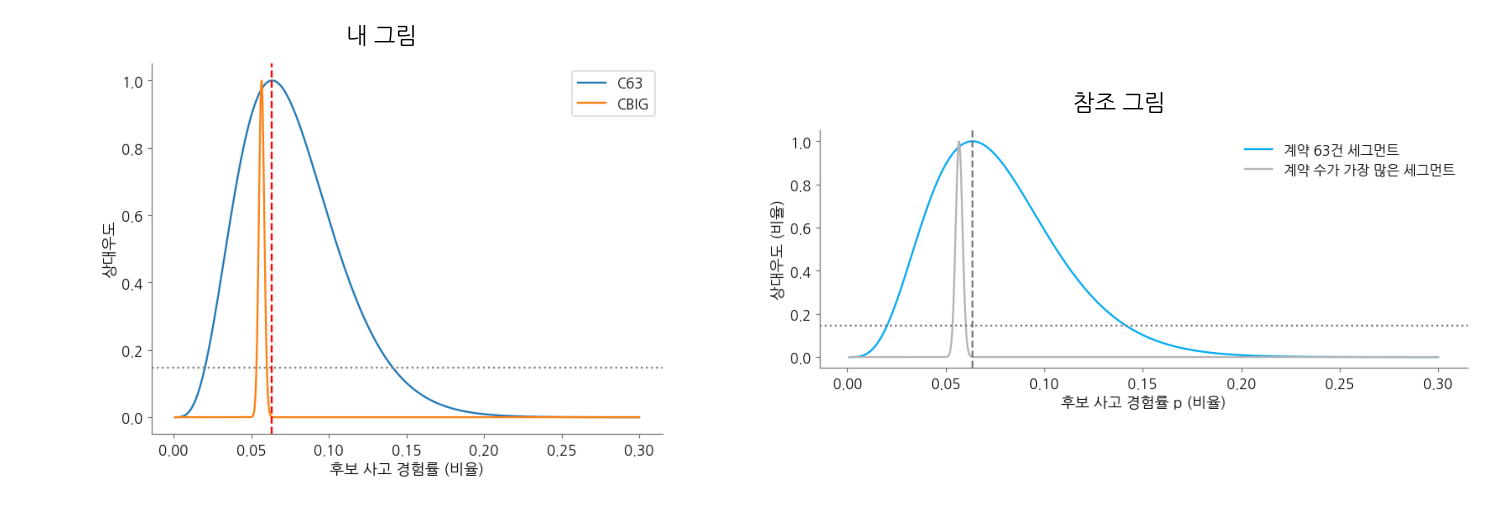

In [7]:
# 미션 3 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
[전제]
seg3, C63, CBIG, p_all 은 이미 있으니 다시 만들지 말고 그대로 사용한다.

[상대우도 세우는 법]
C63, CBIG 각각에 대해 따로 계산한다.
상대우도 = 그 후보의 우도 ÷ 그 세그먼트 최댓값의 우도
(임계값 0.147 = exp(-1.92), 최댓값 우도의 약 15%)

[할 일]
아래 네 가지를 계산/출력하는 코드를 PROMPT 셀의
--- 여기부터 AI 코드 --- 행 아래 작성한다.

1. 63건 세그먼트 상대우도 구간의 상한
   - C63의 상대우도 곡선에서 임계값 0.147 이상인 후보 가운데 가장 큰 값을 찾는다.
   - 단위: 비율, 소수 여섯 자리로 출력

2. 전체 계약 사고 경험률의 상대우도 
   - C63의 상대우도 곡선에서, 가로축이 p_all인 지점의 높이를 찾는다.
   - 단위: 비율, 소수 여섯 자리로 출력

3. 대조용 한 행
   - 두 세그먼트의 구간 길이를 나란히 출력하고, 몇 배 차인지 본다.

4. 그래프 한 장
   - C63 세그먼트 하나, CBIG 세그먼트 하나씩 곡선 그래프를 그리고, 두 곡선을 구분하는 범례(legend)를 단다.
   - 가로축: 후보 사고 경험률 0.001 ～ 0.30, 격자점 1000개 이상
   - 세로축: 상대우도
   - 수직선(axvline): C63 세그먼트의 사고 경험률(p_mle) 자리에 하나
   - 가로선(axhline): 임계값 0.147 자리에 하나 (점선으로, 곡선처럼 보이지 않게)
  - 가로축 이름: 후보 사고 경험률 (비율)
   - 세로축 이름: 상대우도
4. 남길 다섯 행
    - ±2SE 가 좁은 순서로 상위 다섯 세그먼트를 그대로 출력한다.
    - 고치기 전과 후 어떤 세그먼트가 앞자리에 오는지 확인용

[출력 형식]
- 값 두 개(1번, 2번)는 각각 "이름 = 값 단위" 형태로 한 행씩 print 한다.
- 3번 대조용 행도 같은 형식으로 출력한다.
- 그래프는 한 장만 생성한다.
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

def rel_lik(p, n, k):
    p_hat = k / n
    logL = k * np.log(p) + (n - k) * np.log(1 - p)
    logL_max = k * np.log(p_hat) + (n - k) * np.log(1 - p_hat)
    return np.exp(logL - logL_max)

threshold = 0.147
p_grid = np.linspace(0.001, 0.30, 2000)

rl_c63 = rel_lik(p_grid, C63["n"], C63["k"])
rl_cbig = rel_lik(p_grid, CBIG["n"], CBIG["k"])

# 1. C63 구간의 상한
cand_c63 = p_grid[rl_c63 >= threshold]
upper_c63 = cand_c63.max()
lower_c63 = cand_c63.min()
print(f"63건 세그먼트 상대우도 구간의 상한 = {upper_c63:.6f} 비율")

# 2. p_all 지점의 상대우도
rl_at_pall = rel_lik(p_all, C63["n"], C63["k"])
print(f"전체 계약 사고 경험률의 상대우도 = {rl_at_pall:.6f} 비율")

# 3. 대조용 — 구간 길이 비교
cand_cbig = p_grid[rl_cbig >= threshold]
upper_cbig = cand_cbig.max()
lower_cbig = cand_cbig.min()
length_c63 = upper_c63 - lower_c63
length_cbig = upper_cbig - lower_cbig
print(f"구간 길이 = C63 {length_c63:.6f} 비율, CBIG {length_cbig:.6f} 비율, 배율 = {length_c63 / length_cbig:.6f} 배")

# 4. 그래프
plt.figure()
plt.plot(p_grid, rl_c63, label="C63")
plt.plot(p_grid, rl_cbig, label="CBIG")
plt.axvline(C63["p_mle"], color="red", linestyle="--")
plt.axhline(threshold, color="gray", linestyle=":")
plt.xlabel("후보 사고 경험률 (비율)")
plt.ylabel("상대우도")
plt.legend()
plt.show()

> **[문제] 미션 3 에서 상대우도를 잴 때, 후보마다의 로그우도에서 그 세그먼트 최댓값의 로그우도를 빼고 `np.exp` 를 씌우는 것은 무엇을 하는 계산인가요?**
>
> 1. 로그우도를 그 후보가 맞을 확률로 바꾼다
> 2. 임계값 0.147 을 곱해 구간의 양 끝을 잘라 낸다
> 3. 그 후보의 우도를 최댓값의 우도로 나눈 것과 같아, 곡선의 가장 높은 자리를 1 로 맞춘다

## 요율표의 어느 세그먼트까지 이 숫자를 그대로 적어도 되나

> **[과제] 과제 제출 — 요율표 2,323개 세그먼트에 판정 붙이기**
>
> - **무엇을** 세그먼트마다 판정이 적힌 표 한 장과 사람이 다시 볼 계약 수 한 행을 만듭니다.
> - **무엇으로** 오늘 내내 쓴 그 계약 기록 하나로 하고, 준비 셀이 2,323개 세그먼트 집계까지 만들어 둡니다.
> - **인정** 채점이 값 넷과 그림을 통과시킨 노트북에 브리핑 세 문장과 답신을 붙인 것입니다.
> - **예** 계약 3건·사고 2건인 세그먼트는 ±2SE 가 0.544 라 기준값 0.050235 보다 넓어 판정이 「재검토」 로 붙고, 값 행은 「그대로 사용 세그먼트 수 = ○○○ 개」 꼴 한 행입니다.
> 
> - 「PROMPT 셀」을 실행해 값 넷과 그림 한 장을 모두 통과시킵니다.
> - 그 셀의 PROMPT 는 지우지 말고 내가 쓴 그대로 둡니다.
> - 판정 세 가지를 적은 열을 세그먼트 표에 남깁니다.
> - 브리핑 세 문장을 이 절 끝 양식에 채웁니다.
> - 상품팀 답신 세 문장을 그 아래 양식에 채웁니다.
>
> 마감: 2026-09-29T23:59+09:00
>
> **평가 기준**
>
> | 기준 | 이렇게 하면 충족 | 배점 |
> | --- | --- | --- |
> | 문제 정의 | 「PROMPT 셀」의 PROMPT 에 판정 규칙 셋이 내 말로 적혀 있다. | 25 |
> | 검증 설계 | 값 넷과 그림이 모두 채점을 통과했다. | 25 |
> | 오류 탐지 | ±2SE 를 계산할 수 없는 세그먼트를 먼저 제외한 근거를 브리핑에 서술했다. | 25 |
> | 해석·보고 | 답신이 세그먼트 수와 계약 수를 단위와 함께 제시한다. | 25 |
>
> 제출은 LMS 레슨 화면의 과제 카드에서 GitHub 또는 Google Drive 링크로 합니다(이 파일에 적으면 제출되지 않습니다).

### 과제 — 요율표 2,323개 세그먼트에 판정을 붙인다

#### 할 일 — 과제 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 아래 만들 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
3. 셀을 클릭한 채 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
4. 실행 결과(출력)에 찍히는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.
5. 이 절 끝 양식에 브리핑 세 문장과 상품팀 답신을 채워 제출합니다.

**이 과제의 질문** — 요율표 2,323개 세그먼트 가운데 어디를 그대로 쓰고 어디를 사람이 다시 봐야 합니까?

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `df` | 계약 678,013행 표, 열은 `ClaimNb` · `HasClaim` | 고정 |
| `seg3` | 세그먼트 2,323행 표, 열은 `n` · `k` · `c` · `p_mle` | 고정 |
| `p_all` | 전체 계약(회사 전체)의 사고 경험률, 단위 비율 · 판정 기준값 | 고정 |

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 다 나오게 합니다.

1. **판정 열 하나** — 세그먼트마다 셋 중 하나를 적어 `seg3` 의 열로 남깁니다
   - 「계산 불가」 : 사고가 0건이거나 계약 전부가 사고를 겪은 세그먼트
   - 「재검토」 : 남은 세그먼트 중 ±2SE 가 `p_all` 보다 넓은 세그먼트
   - 「그대로 사용」 : 나머지 세그먼트
2. **그대로 사용 세그먼트 수** — 단위 개 · 정수
3. **재검토·계산 불가 세그먼트에 속한 계약 수** — 단위 건 · 정수
   - 세그먼트 수가 아니라 그 세그먼트들의 `n` 을 더한 값입니다
4. **재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수** — 단위 건 · 정수
5. **계약당 사고 건수** — 단위 건/계약 · 소수 여섯 자리
   - 이 값만 0/1 변수가 아닙니다. 사고 유무가 아니라 사고 건수 열의 평균이에요
6. **그래프 한 장** — 가로축은 세그먼트의 계약 수, 세로축은 그 세그먼트의 ±2SE 인 산점도
   - 점 : 세그먼트 하나에 점 하나, 모두 2,323개
   - 가로축 눈금 : 로그 눈금
   - 색 : 판정 셋을 색으로 구분하고 범례를 답니다
   - 가로축 이름 : 「세그먼트의 계약 수 (건, 로그 눈금)」
   - 세로축 이름 : 「±2SE (비율)」

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Poisson_pmf.svg" width="520" height="403"/>
<p align="center"><em>▲ 만들 것 5번 — 사고 건수처럼 0, 1, 2 … 로 세는 값의 분포. 가로축이 건수 k, 세로축이 그 건수가 나올 확률이다. 평균이 1 이면 0건과 1건에 확률이 몰리고, 평균이 4 나 10 으로 커지면 최댓값 지점이 오른쪽으로 옮겨 간다. 계약당 사고 건수는 이 분포의 평균이고, 오늘의 0/1 변수와는 다른 숫자가 된다 (출처: Wikimedia Commons, Poisson pmf.svg)</em></p>

**출력 형식** — 값 넷을 「이름 = 값 단위」 꼴로 한 행씩 `print` 합니다. 그래프는 한 장이고, 표는 파일로 내보내지 않습니다.

#### 프롬프트에 넣을 것(힌트)

- **판정 순서** — 셋을 어떤 차례로 적용할지 적습니다. 순서가 빠지면 사고 0건 세그먼트가 ±2SE 0 을 달고 「그대로 사용」 쪽으로 넘어갑니다.
- **고정할 이름** — `df` · `seg3` · `p_all` 은 이미 있으니 다시 만들지 말라고 적습니다.
- **출력** — 값 넷의 이름과 단위, 그리고 「계약당 사고 건수」를 소수 몇 자리까지 찍을지.
- **그래프** — 가로축·세로축에 무엇을 놓을지 · 가로축 눈금 · 색으로 구분할 것 · 이름과 범례.

**막히면** — AI 튜터에게 「판정 셋을 어떤 순서로 적용해야 계산 불가 세그먼트가 섞이지 않나요」 처럼 물어보세요.

#### 판정하기 전에 — 몇 할일지 골라 보세요

판정을 붙이기 전에, 2,323개 세그먼트 가운데 「그대로 사용」이 차지할 몫을 먼저 골라 두세요.

> **[예측] 요율표 2,323개 세그먼트 가운데 「그대로 사용」 판정을 받는 세그먼트는 몇 할쯤일까요?**
>
> 1. 1할 미만 — 계약이 적은 세그먼트가 대부분이라 거의 다 사람이 다시 본다
> 2. 4할 안팎 — 세그먼트 수로는 절반 가까이 갈린다
> 3. 8할 이상 — 계약 수가 넉넉한 세그먼트가 대부분이다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

고른 이유를 한 문장 적고, 세그먼트 수가 아니라 계약 수로 세면 그 몫이 어느 쪽으로 움직일지도 적어 두세요.

<details class="lms-extra"><summary>배경 — 상품팀의 되물음과 판정 기준값이 회사 전체 값인 까닭</summary>

상품팀이 새 요율표 초안을 받아 갔다가 되물어 왔습니다 — **"세그먼트 2,323개에 숫자가 다 채워져 있는데, 어느 세그먼트를 그대로 쓰고 어느 세그먼트를 사람이 다시 봐야 하는지 표에 적어 주세요."** 미션 2 에서 ±2SE 를 계산할 수 없는 세그먼트 759개는 이미 구분했으니, 남은 세그먼트에 기준선을 하나 더 긋는 일입니다.

±2SE 가 회사 전체 값 자체보다 넓다면, 그 세그먼트의 숫자는 요율 단위 위에서 어느 값이라고 말할 수 없습니다. 이론 3절에서 계약 67만 8천 건의 ±2SE 를 두고 「요율을 5.0% 로 적을지 5.1% 로 적을지가 이 안에서 갈린다」로 읽었던 그 기준이에요. 세그먼트마다 제 값을 기준값으로 삼으면 측정 단위가 세그먼트마다 달라집니다.

계약 3건에 사고 2건인 세그먼트가 그 예예요. 그 세그먼트의 값은 0.667 이고 ±2SE 는 0.544 라, 제 값보다는 좁아 통과해 버립니다. 기준값 하나를 회사 전체 값으로 고정해야 2,323개 세그먼트를 같은 기준으로 평가합니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Empirical_Rule.PNG" width="640" height="464"/>
<p align="center"><em>▲ 평균에서 좌우로 표준편차 두 개만큼 벌린 구간이 데이터의 95% 를 덮는다는 경험 규칙 — 표준편차 한 배 구간이 68%, 두 배 구간이 95%, 세 배 구간이 99.7% 다. ±2SE 구간을 판정 기준으로 쓰는 근거가 가운데 95% 이고, 과제는 그 구간을 회사 전체 값과 견줘 세그먼트를 구분한다 (출처: Wikimedia Commons, Empirical Rule.PNG)</em></p>

「계약당 사고 건수」만 측정 단위가 다릅니다. 오늘 내내 센 것은 「겪었는가」였고, 이 값은 「몇 건인가」예요. 이론 4절에서 포아송 MLE 가 표본평균으로 떨어진다고 본 그 값이라, 사고 건수 열의 평균을 그대로 찍으면 됩니다. 두 값이 얼마나 갈리는지는 통과 뒤 열리는 완성본에서 확인하세요.

</details>

In [8]:
# 과제 · 준비 — 읽고 실행만 합니다. 이 셀이 과제에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 맨 위 두 셀을 실행한 뒤에는 이 절만 따로 열어도 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)      # 오늘 고정한 전처리 두 규칙 — 미션 1·2·3 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)
    df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)             # 오늘 분석할 변수 — 사고를 겪었는가 아닌가

# 쓸 변수 1 — 세그먼트 표를 미션 2·3 과 같은 규칙으로 다시 셉니다 (앞에서 덧붙인 열은 남기지 않습니다)
seg3 = (df.groupby(["Region", "VehBrand", "VehPower"], observed=True)
          .agg(n=("IDpol", "size"),        # n — 그 세그먼트의 계약 수 (건)
               k=("HasClaim", "sum"),      # k — 그중 사고를 겪은 계약 수 (건)
               c=("ClaimNb", "sum"))       # c — 그 세그먼트의 사고 건수 합 (건)
          .reset_index())
seg3["p_mle"] = seg3["k"] / seg3["n"]      # p_mle — 그 세그먼트의 사고 경험률 = k / n (비율)

p_all = float(df["HasClaim"].mean())       # 쓸 변수 2 — 전체 계약의 사고 경험률 (비율) = 판정 기준값

unmeasurable_segs = int(((seg3["k"] == 0) | (seg3["k"] == seg3["n"])).sum())
print(f"세그먼트 {len(seg3):,}개 | 컬럼 {list(seg3.columns)}")
print(f"판정 기준값 — 전체 계약의 사고 경험률 p_all = {p_all:.6f} 비율")
print(f"±2SE 를 계산할 수 없는 세그먼트 = {unmeasurable_segs} 개 — 미션 2 에서 구분한 그 세그먼트들입니다")
print(f"세그먼트의 계약 수 : 가장 적은 세그먼트 {int(seg3['n'].min()):,}건"
      f" · 가운뎃값 {int(seg3['n'].median()):,}건"
      f" · 가장 많은 세그먼트 {int(seg3['n'].max()):,}건")
print(f"전체 계약 {int(seg3['n'].sum()):,}건 — 세그먼트의 계약 수를 모두 더한 값입니다")
print("\n쓸 수 있는 이름 : df (ClaimNb · HasClaim 열) · seg3 (n · k · c · p_mle 열)"
      " · p_all (전체 계약의 사고 경험률, 비율)")

세그먼트 2,323개 | 컬럼 ['Region', 'VehBrand', 'VehPower', 'n', 'k', 'c', 'p_mle']
판정 기준값 — 전체 계약의 사고 경험률 p_all = 0.050235 비율
±2SE 를 계산할 수 없는 세그먼트 = 759 개 — 미션 2 에서 구분한 그 세그먼트들입니다
세그먼트의 계약 수 : 가장 적은 세그먼트 1건 · 가운뎃값 41건 · 가장 많은 세그먼트 18,042건
전체 계약 678,013건 — 세그먼트의 계약 수를 모두 더한 값입니다

쓸 수 있는 이름 : df (ClaimNb · HasClaim 열) · seg3 (n · k · c · p_mle 열) · p_all (전체 계약의 사고 경험률, 비율)


그대로 사용 세그먼트 수 = 960 개
재검토·계산 불가 세그먼트 계약 수 = 28491 건
재검토 세그먼트 중 계약 수 최대값 = 147 건
계약당 사고 건수 = 0.053179 건/계약

──────────────────────────────────────────────────────
◼ 과제 채점 결과
✅ 그대로 사용 세그먼트 수 (개) — 출력에서 960 를 찾았습니다
✅ 재검토·계산 불가 세그먼트에 속한 계약 수 (건) — 출력에서 28,491 를 찾았습니다
✅ 재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수 (건) — 출력에서 147 를 찾았습니다
✅ 계약당 사고 건수 (건/계약) — 출력에서 0.053179 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
──────────────────────────────────────────────────────


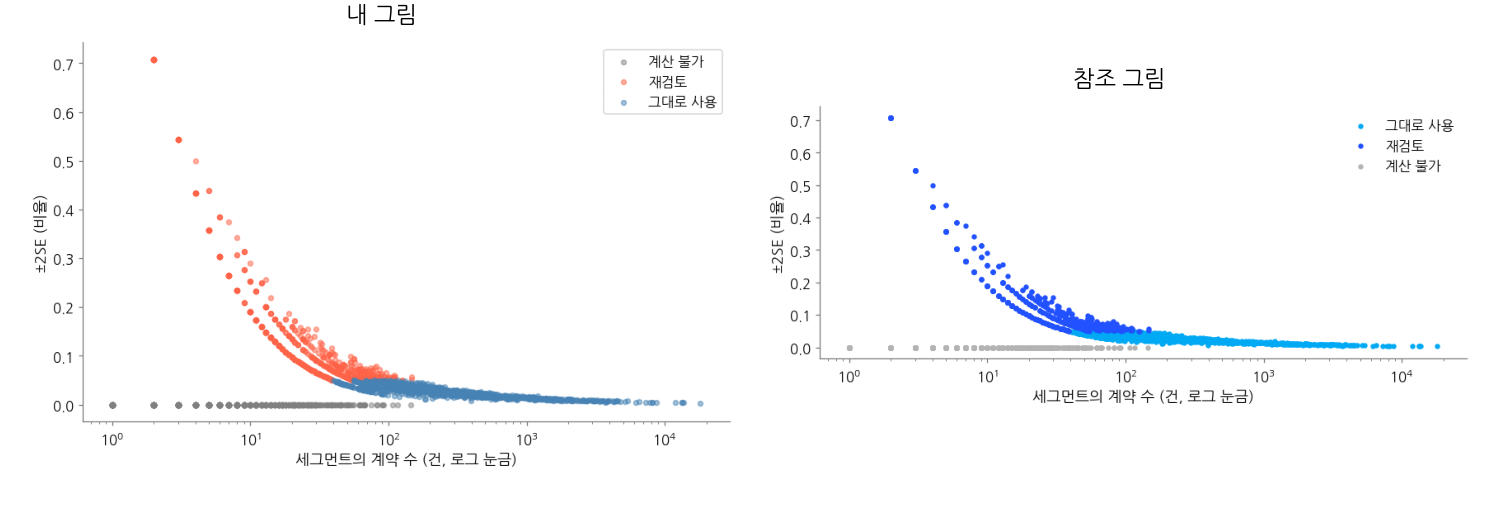

In [9]:
# 과제 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
[전제]
df, seg3, p_all은 이미 정의되어 있으니 다시 만들지 말고 그대로 사용한다.

[할 일]
1. 판정 열 하나
   - 세그먼트마다 아래 셋 중 하나를 적어 seg3의 열로 남긴다.
   - 「계산 불가」: 사고가 0건이거나 계약 전부가 사고를 겪은 세그먼트
   - 「재검토」: 남은 세그먼트 중 ±2SE 가 p_all 보다 넓은 세그먼트
   - 「그대로 사용」: 나머지 세그먼트
   - 반드시 이 순서로 판별하여 계산 불가 세그먼트가 재검토, 그대로 사용 쪽으로 섞이지 않게 한다.

2. 그대로 사용 세그먼트 수
   - 판정 = 「그대로 사용」인 세그먼트 개수
   - 단위: 개, 정수로 출력

3. 재검토·계산 불가 세그먼트에 속한 계약 수
   - 판정이 「재검토」 또는 「계산 불가」인 세그먼트들의 n을 모두 더한 값.
   - 세그먼트 개수가 아니라 그 세그먼트들의 n의 합이다.
   - 단위: 건, 정수로 출력

4. 재검토 세그먼트 중 계약 수가 가장 많은 세그먼트의 계약 수
   - 판정 = 「재검토」인 세그먼트들 중 n이 가장 큰 값.
   - 단위: 건, 정수로 출력

5. 계약당 사고 건수
   - 사고 유무(HasClaim)가 아니라 ClaimNb(사고 건수) 열의 평균이다.
   - 단위: 건/계약, 소수 여섯 자리로 출력

6. 그래프 한 장 - 산점도
   - 가로축: 세그먼트의 계약 수 n (세그먼트당 점 하나, 총 2,323개), 로그 눈금으로 설정한다.
   - 세로축: 그 세그먼트의 ±2SE
   - 세 가지 판정을 색으로 구분하고, 범례를 단다.
   - 가로축 이름: 세그먼트의 계약 수 (건, 로그 눈금)
   - 세로축 이름: ±2SE (비율)

[출력 형식]
- 값 넷(2~5번)은 각각 "이름 = 값 단위" 형태로 한 행씩 print한다.
- 그래프는 한 장만 생성한다.
- 표는 파일로 내보내지 않는다.
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

n = seg3["n"]
p = seg3["p_mle"]
se = np.sqrt(p * (1 - p) / n)
margin = 2 * se

calc_impossible = (seg3["k"] == 0) | (seg3["k"] == n)
reexamine = (~calc_impossible) & (margin > p_all)
use_as_is = (~calc_impossible) & (~reexamine)

seg3["판정"] = np.select(
    [calc_impossible, reexamine, use_as_is],
    ["계산 불가", "재검토", "그대로 사용"],
    default=""
)
seg3["margin"] = margin

use_count = int((seg3["판정"] == "그대로 사용").sum())
review_or_impossible_n = int(seg3.loc[seg3["판정"].isin(["재검토", "계산 불가"]), "n"].sum())
max_review_n = int(seg3.loc[seg3["판정"] == "재검토", "n"].max())
claims_per_contract = df["ClaimNb"].mean()

print(f"그대로 사용 세그먼트 수 = {use_count} 개")
print(f"재검토·계산 불가 세그먼트 계약 수 = {review_or_impossible_n} 건")
print(f"재검토 세그먼트 중 계약 수 최대값 = {max_review_n} 건")
print(f"계약당 사고 건수 = {claims_per_contract:.6f} 건/계약")

colors = {"계산 불가": "gray", "재검토": "tomato", "그대로 사용": "steelblue"}
fig, ax = plt.subplots(figsize=(8, 5))
for label, color in colors.items():
    mask = seg3["판정"] == label
    ax.scatter(seg3.loc[mask, "n"], seg3.loc[mask, "margin"],
               c=color, label=label, alpha=0.5, s=15)
ax.set_xscale("log")
ax.set_xlabel("세그먼트의 계약 수 (건, 로그 눈금)")
ax.set_ylabel("±2SE (비율)")
ax.legend()
plt.show()

# [브리핑]  
- 결론: 그대로 쓸 세그먼트는 960 개이고, 사람이 다시 볼 세그먼트는 1,363 개입니다.

- 위험: 다시 볼 세그먼트에는 속한 계약 28,491건에 대해서는 세그먼트 추정값 대신 회사 전체 사고 경험률(0.050235)이나 축소 추정 값을 임시로 적용하고, 표본이 충분히 쌓이기 전까지는 세그먼트 고유 요율을 확정하지 말아야 합니다.

- 코드가 답을 만드는 방식: 각 세그먼트의 흔들림 폭(±2SE)이 회사 전체 값(0.050235)보다 크면 "이 숫자는 못 믿는다"고 판단하여 재검토로 분류했습니다.

# [상품팀 답신]
- 결론: 요율표에서 그대로 쓰셔도 되는 세그먼트는 960 개입니다.

- 근거: 사고가 0건이거나 전건인 세그먼트는 흔들림 폭 계산 자체가 무의미해 「계산 불가」로, 나머지는 추정값의 흔들림 폭(±2SE)이 회사 전체 값(0.050235)보다 좁으면 「그대로 사용」, 넓으면 「재검토」로 판정했습니다.

- 한계: 나머지 1,363개 세그먼트는 표본이 적어 추정값을 요율표에 그대로 적기엔 불확실성이 크므로, 계약이 더 쌓일 때까지는 전체 평균값을 임시로 적용하거나 다른 방안을 검토해주시길 바랍니다.

**브리핑 세 문장** — 아래 세 문장을 이 셀에 그대로 채워 제출합니다. 값과 그림이 모두 채점을 통과한 뒤에 씁니다. 위험 문장에는 사람이 다시 볼 세그먼트에 속한 계약 수를 함께 적어 두면 상품팀이 일의 크기를 바로 봅니다.

> **결론**: 그대로 쓸 세그먼트는 ____ 개이고, 사람이 다시 볼 세그먼트는 ____ 개입니다.
>
> **위험**: ____ — 다시 볼 세그먼트에 속한 계약과 그 계약에 무엇을 적을지 한 문장
>
> **코드가 답을 만드는 방식**: ____ — ±2SE 하나로 어느 기준선을 그었는지 한 문장

**상품팀 답신** — 브리핑 바로 아래에 세 문장을 채웁니다. 브리핑이 우리 팀에 쓰는 글이라면, 답신은 상품팀에 보내는 글입니다.

> **결론**: 요율표에서 그대로 쓰셔도 되는 세그먼트는 ____ 개입니다.
>
> **근거**: ____ — 이 판정을 어떤 기준값으로 구분했는지 한 문장
>
> **한계**: ____ — 다시 볼 세그먼트의 숫자를 지금 어떻게 다뤄야 하는지 한 문장

## 오늘의 정리 — 내일은 기간으로 나눈 사고율로

오늘의 질문은 「계약 하나가 사고를 겪을 확률을 우리 기록에서 얼마로 추정하고, 그 숫자를 요율표의 어느 세그먼트까지 그대로 옮겨 적어도 되는가」였습니다. 한 문장으로 답하면 이렇습니다 — **전체 계약에서는 0.050235 이고, 그 값을 그대로 옮겨 적어도 되는 세그먼트는 ±2SE 가 회사 전체 값보다 좁은 세그먼트뿐입니다.**

| 오늘 물은 것 | 우리가 얻은 답 |
|---|---|
| 전체 계약의 사고 경험률은? | 0.050235 비율 — 수치 최적화가 찾은 값과 k / n 이 같은 값이다 |
| ±2SE 가 0 으로 찍힌 세그먼트는 무엇인가? | 추정값이 안정된 세그먼트가 아니라, 사고가 0건이거나 계약 전부가 사고를 겪어 계산만 0 이 된 세그먼트 759개다 |
| 계약 수가 적은 세그먼트에 적어도 되는 값은? | 값 하나가 아니라 우도로 구한 구간으로 보고한다 — 63건 세그먼트는 그 구간의 좌우 길이가 다르다 |
| 요율표에 그대로 옮길 세그먼트는? | ±2SE 가 회사 전체 값보다 넓은가 하나로 갈라, 넓은 쪽을 사람이 다시 보게 남긴다 |

오늘 남는 결과물은 숫자 하나가 아니라 **판정이 붙은 표 한 장**입니다. 추정값과 ±2SE 구간을 함께 읽는 습관, 그리고 ±2SE 구간이 추정값 자체보다 넓은 세그먼트를 따로 분류하는 규칙이 그 표를 만들었어요.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/MLfunctionbinomial-en.svg" width="560" height="373"/>
<p align="center"><em>▲ 오늘의 요약 — 계약 10건 가운데 사고를 겪은 계약이 1건·3건·6건일 때의 우도 곡선. 최댓값이 0.1 · 0.3 · 0.6 으로 k / n 자리에 그대로 있어도 곡선 셋이 모두 완만해, 추정값과 ±2SE 구간을 함께 보고해야 한다 (출처: Wikimedia Commons, MLfunctionbinomial-en.svg)</em></p>

가로축이 후보 비율이고, 세로축이 그 후보의 우도입니다. 곡선 셋은 사고 1건·3건·6건 순으로 빨강 · 초록 · 파랑이고, 그림 안 범례의 t 가 사고를 겪은 계약 수입니다.

<details class="lms-extra"><summary>숫자로 맞춰 보기 — 미션 3 과 과제를 낸 뒤 펼쳐 보세요</summary>

미션 3 의 구간은 0.020 부터 0.141 까지, 과제에서 그대로 쓸 세그먼트는 960개(전체 계약의 95.8%)입니다.

</details>

## 내일 예고 — 계약마다 기간이 다르다

오늘은 계약이 사고를 겪었는지만 0 과 1 로 셌습니다. 그런데 어떤 계약은 열두 달을 유지했고 어떤 계약은 두 달 만에 끝났어요. 두 계약의 1 을 같은 무게로 세는 것이 맞을까요.

내일은 분석 지표를 **기간으로 나눈 사고율**로 바꾸고, 오늘 접어 둔 `Exposure` 열을 분모로 꺼냅니다. 세그먼트도 마력을 뺀 지역 × 차종으로 넓혀 잡고요. 그러고도 계약 수가 적은 세그먼트는 여전히 적으니, 데이터 바깥의 사전분포(정규화 항)를 더해 그 세그먼트의 추정값을 안정시키는 방법까지가 내일의 몫입니다. 오늘 세운 우도가 그 식 안에 한 항으로 그대로 들어갑니다.

마무리는 두 문장이면 충분합니다. 오늘 채점이 열어 준 완성본과 내 코드가 갈렸던 자리 한 곳, 그리고 그 자리에서 배운 것 한 문장. 팀 채널에 올려 두고 다른 사람의 두 문장을 읽는 것이 오늘의 마지막 복습이에요.

<div style="background:#F2F2F2;color:#000000;padding:28px;border-radius:12px;border:1px solid #E6E6E6;margin-top:16px;border-left:4px solid #051C2C">
<h2 style="color:#000000;margin:0 0 8px 0">수고했습니다 — 모형추정 Day 1 완료</h2>
<div style="color:#656565">우도로 값 하나를 추정하고, ±2SE 구간을 기준으로 그 값을 그대로 써도 되는 세그먼트를 구분했습니다.<br/>내일은 계약마다 다른 기간을 값 안에 넣습니다.</div>
</div>

> **[문제] 재검토 세그먼트에 무엇을 적어 보낼까**
>
> 과제에서 만든 표를 상품팀에 넘기려는데, 「재검토」로 판정된 세그먼트에는 적어 보낼 요율이 비어 있습니다. 상품팀은 "요율이 비어 있는 자리가 있으면 시스템에 못 올린다"고 답했어요. (가) 재검토 세그먼트에 그 세그먼트의 사고 경험률을 그대로 적으면 무엇이 문제인지, (나) 대신 무엇을 적어 넣을지 후보 하나와 그 근거를, (다) 그 임시값을 언제 걷어낼 수 있는지를 — 세 문장으로 적어 보세요.